# Problem 1: ACSL Intermediate

In [ ]:
#Quartile Function
import pandas as pd

df = pd.DataFrame({'values': [3, 5, 6, 16, 18, 18, 25, 26, 27, 27,30, 32, 32, 43, 54, 90]})

summary = df['values'].describe()
q1 = summary['25%']
q2 = summary['50%']  # Median
q3 = summary['75%']

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)

Q1: 17.5
Q2: 26.5
Q3: 32.0


In [ ]:
import numpy as np

data = [3, 5, 6, 16, 18, 18, 25, 26, 27, 27,30, 32, 32, 43, 54, 90]

q1 = np.quantile(data, 0.25)
q2 = np.quantile(data, 0.50)  # Equivalent to the median
q3 = np.quantile(data, 0.75)

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)

Q1: 17.5
Q2: 26.5
Q3: 32.0


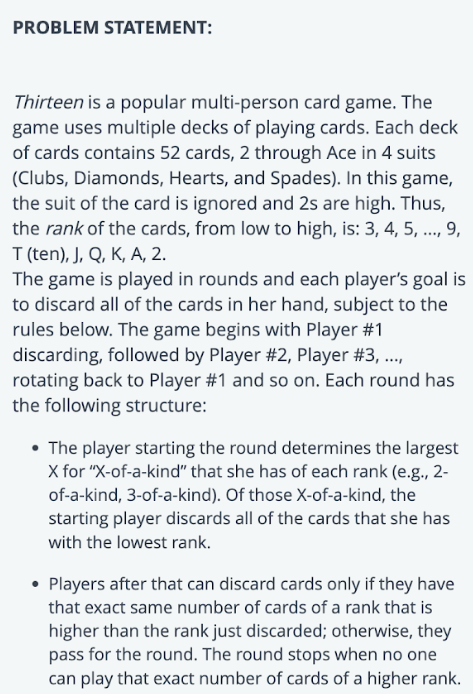

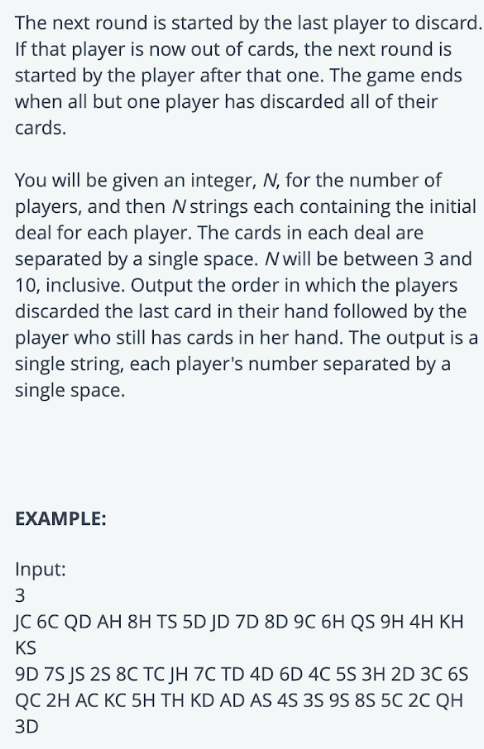

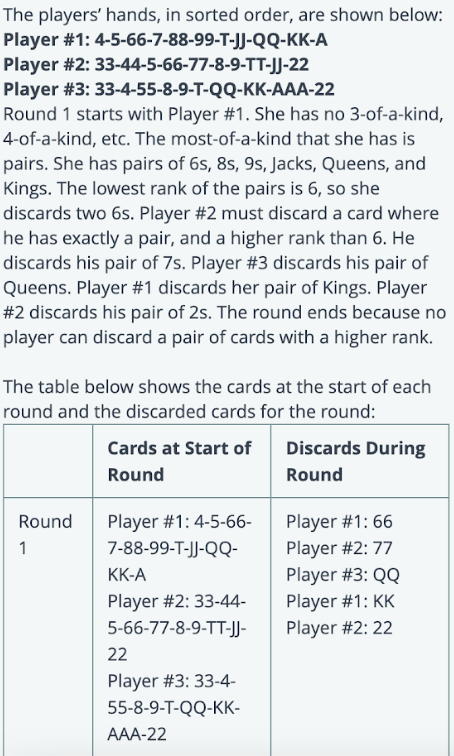

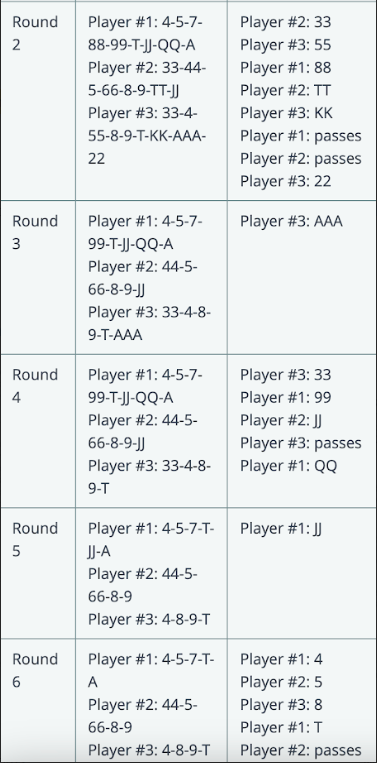

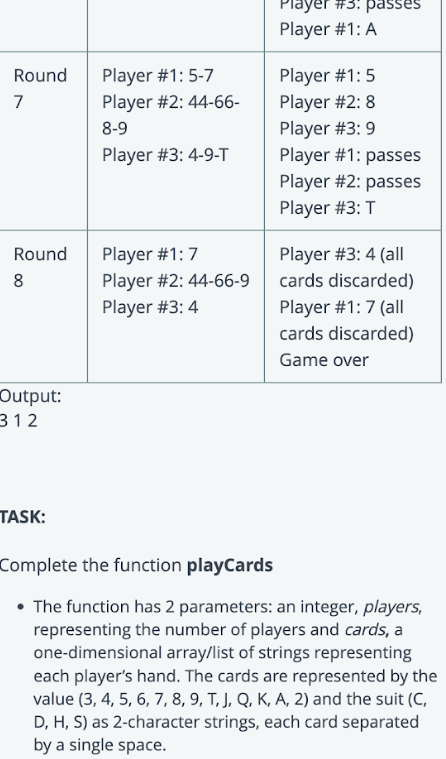

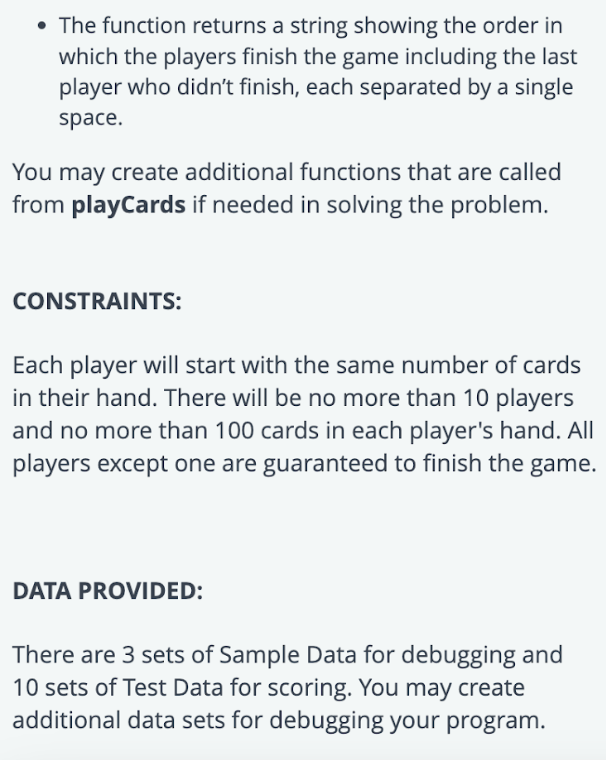

In [ ]:
def playCards (players, cards_arr):
  #main
  ...

def seperateCards (players, cards_arr):
    p1 = cards_arr[0]
    p2 = cards_arr[1]
    p3 = cards_arr[2]

    p1 = sortCards(p1)
    p2 = sortCards(p2)
    p3 = sortCards(p3)

    # p1_count = count_and_store(p1)
    # p2_count = count_and_store(p2)
    # p3_count = count_and_store(p3)

    # print(p1_count)
    # print(p1)

def sortCards (cards):
  card_order = ["3", "4", "5", "6", "7", "8", "9", "T", "J", "Q", "K", "A", "2"]
  c_arr = cards.split()
  c_arr = [item[0] for item in c_arr]
  arranged_cards = sorted(c_arr, key=lambda card: card_order.index(card))
  return arranged_cards

def count_and_store(arr):
  # Initialize the result array
  result = []

  # Iterate over the array
  i = 0
  while i < len(arr):
    # Get the current element
    element = arr[i]
    count = 1
    j = i + 1
    while j < len(arr) and arr[j] == element:
      count += 1
      j += 1
    result.extend([element, count])
    i = j
  return result

def playRound (cards, player):
  if player == 0:
    playFirstTurn(p1)
  #Search players cards for X of a kind (4 of a kind, 3...). Takes the higest of a kind and plays the lowest value of that
  #If turn is not the first turn of the round, gives user the option to play or pass
  #When play =! first turn, then looks for cards to match value/ play higher value of X of that kind if playing and not passing
  #start with p1, store who play's last and return it to get who starts next round
  ...

def playFirstTurn (player):
  pc = count_and_store(player)
  length = len(pc)
  max = 0
  for i in range (0, length, 2):
    if pc[i] > max:
      max = pc[i]
  ind = pc.index(max)
  print(player, "plays", max, "of a kind of", pc[ind - 1])
  player.remove(max)
  return player

def playTurn():
  #General play turn function, where you take previously played turn
  #and then play using that, you can pass as an option
  ...

def endRound ():
  #Check if all players pass, if you pass once, you always pass
  pass

num_players = 3
cards = ['JC 6C QD AH 8H TS 5D JD 7D 8D 9C 6H QS 9H 4H KH KS',
         '9D 7S JS 2S 8C TC JH 7C TD 4D 6D 4C 5S 3H 2D 3C 6S',
         'QC 2H AC KC 5H TH KD AD AS 4S 3S 9S 8S 5C 2C QH 3D']
seperateCards(num_players, cards)

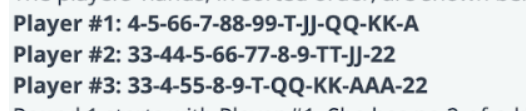

In [ ]:
def playCards(players, cards):
    # Helper function to convert card ranks to numbers
    def card_value(card):
        values = {'3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'T': 10, 'J': 11, 'Q': 12, 'K': 13, 'A': 14, '2': 15}
        return values[card[0]]

    # Sort and convert each player's hand into numerical values
    hands = [[card_value(card) for card in hand.split()] for hand in cards]
    for hand in hands:
        hand.sort(reverse=True)  # Sort in descending order

    # Initialize game state
    finish_order = []
    round_num = 1

    # Play until all but one player has finished
    while len(finish_order) < players - 1:
        # Track the number of passes in each round
        passes = 0

        # Iterate over each player in the current round
        for current_player in range(players):
            # Skip finished players
            if current_player in finish_order:
                continue

            hand = hands[current_player]
            if not hand:
                finish_order.append((current_player, round_num))
                continue

            # Determine the play for the current player
            play_rank = hand[0]
            play_count = hand.count(play_rank)

            # Check if any other player can make a higher play
            can_play = False
            for next_player in range(players):
                if next_player in finish_order or next_player == current_player:
                    continue
                next_hand = hands[next_player]
                if next_hand and max(next_hand) > play_rank:
                    can_play = True
                    break

            # If no other player can play and the current player still has cards, make a play
            if not can_play:
                # Discard the cards
                hand[:] = [card for card in hand if card != play_rank]
                # Check if the current player has finished
                if not hand:
                    finish_order.append((current_player, round_num))
                # Reset passes
                passes = 0
            else:
                # Player cannot make a play, increment passes
                passes += 1

        # If all players passed, start the next round
        if passes == players:
            round_num += 1

    # Sort the finish order based on the round number and player number
    finish_order.sort(key=lambda x: (x[1], x[0]))

    # Return the order in which players finish
    return ' '.join(str(player + 1) for player, _ in finish_order)

# Test case
print(playCards(3, [
    "JC 6C QD AH 8H TS 5D JD 7D 8D 9C 6H QS 9H 4H KH KS",
    "9D 7S JS 2S 8C TC JH 7C TD 4D 6D 4C 5S 3H 2D 3C 6S",
    "QC 2H AC KC 5H TH KD AD AS 4S 3S 9S 8S 5C 2C QH 3D"
]))

1 3


#Problem 2: Data Analysis

Download 2020 report from https://nrc.uscg.mil/. Read all the sheets and merge data as a single data frame.

Note:

* Calls is primary sheet
* Seqnos is primary key
* Responsible Company should be related to BP companies
* Collect data from all the sheets and taking Calls as primary table, apply joins to create a single data frame

In [ ]:
#Merge the many tables based on the the unqiue sequence number from "Calls"
#Problem - Some tables don't have all sequence numbers

In [ ]:
import pandas as pd

# Path to your Excel file
excel_file = 'CY20.xlsx'

# Read the Excel file
xls = pd.ExcelFile(excel_file)

# Get the sheet names
sheet_names = xls.sheet_names

# Create a dictionary to store the DataFrames
dfs = {}

# Loop through each sheet and read it into a DataFrame
for sheet_name in sheet_names:
    dfs[sheet_name] = xls.parse(sheet_name)

# Accessing the DataFrames
df_sheet1 = dfs['CALLS']
df_sheet2 = dfs['INCIDENT_COMMONS']
df_sheet3 = dfs['INCIDENT_DETAILS']
df_sheet4 = dfs['INCIDENTS']
df_sheet5 = dfs['MATERIAL_INVOLVED']
df_sheet6 = dfs['MATERIAL_INV0LVED_CR']
df_sheet7 = dfs['TRAINS_DETAIL']
df_sheet8 = dfs['DERAILED_UNITS']
df_sheet9 = dfs['VESSELS_DETAIL']
df_sheet10 = dfs['MOBILE_DETAILS']

# Now you can work with each DataFrame individually
df_sheet1.head()
df_sheet2.head()
df_sheet3.head()

In [ ]:
md = pd.merge(df_sheet1, df_sheet2, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet3, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet4, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet5, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet6, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet7, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet8, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet9, on='SEQNOS', how='outer')
md = pd.merge(md, df_sheet10, on='SEQNOS', how='outer')
md

In [ ]:
non_null_counts = md.notnull().sum()
non_nan_columns = non_null_counts[non_null_counts < 5000].index.tolist()
# all_nan_columns will be a list of column names
non_nan_columns
merged_df = md.drop(columns=non_nan_columns)

In [ ]:
merged_df.info(verbose=True, show_counts=True)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Group data and calculate counts
incident_counts = merged_df.groupby(['TYPE_OF_INCIDENT', 'FIRE_INVOLVED'])['FIRE_INVOLVED'].count().reset_index(name='count')

# Create scatter plot
fig, ax = plt.subplots()

# Plot incidents with fire involved ('Y') as 'X'
fire_involved = incident_counts[incident_counts['FIRE_INVOLVED'] == 'Y']
ax.scatter(fire_involved['TYPE_OF_INCIDENT'], fire_involved['count'], marker='x', label='Fire Involved (Y)')

# Plot incidents without fire ('N') as 'O'
no_fire = incident_counts[incident_counts['FIRE_INVOLVED'] == 'N']
ax.scatter(no_fire['TYPE_OF_INCIDENT'], no_fire['count'], marker='o', label='No Fire (N)')

# Customize the plot
plt.title('Incident Count with Fire Involvement')
plt.xlabel('Type of Incident')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend()

# Display the plot
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the bar plot
plt.figure(figsize=(20, 10))
sns.countplot(x='RESPONSIBLE_STATE', data=merged_df)

# Customize the plot (optional)
plt.title('Count of Incidents by Responsible State')
plt.xlabel('Responsible State')
plt.ylabel('Count')
plt.xticks(rotation=90, ha='right')  # Rotate x-axis labels if needed

# Display the plot
plt.show()

#Problem 3: Model and Hypotheses: Examining the Therapeutic Touch

##What is the Therapeutic Touch

The Therapeutic Touch (TT) is the idea that everyone can feel the Human Energy Field (HEF) around individuals. Those who practice TT have described different people's HEFs as "warm as Jell-O" and "tactile as taffy."

TT was a popular technique used throughout the 20th century that was toted as a great way to bring balance to a person's health. Certain practitioners claim they have the ability to feel the HEF and can massage it in order to promote health and relaxation in individuals.

**Emily Rosa**

Emily Rosa was a 4th grade student who was very familiar with the world of TT, thanks to her parents, who were both medical practitioners and skeptics of TT.

For her 4th grade science fair project, Emily decided to test whether or not TT practitioners could truly interact with a person's HEF. She later went on to publish her work in TT, becoming the youngest person to have a research paper published in a peer reviewed medical journal.

**Emily's Experiment**

Emily's experiment was clean, simple, and effective. Due to her parents' occupations in the medical field, she had wide access to people who claimed to be TT practitioners.

Emily took 21 TT practitioners and used them for her science experiment. She would take a TT practitioner and ask them to extend their hands through a screen (which they can't see through). Emily would be on the other side and would flip a fair coin. Depending on how the coin landed, she would put out either her left hand or her right hand. The TT practitioner would then have to answer which hand Emily put out. If a pracitioner could truly interact with a person's HEF, it would be expected that they answered correctly.

Overall, through 210 samples, the practitioner picked the correct hand 44% of the time.

Emily's main goal here was to test whether or not the TT practicioners' guesses were random, like the flip of a coin. In most medical experiments, this is the norm. We want to test whether or not the treatment has an effect, not whether or not the treatment actually works.

We will now begin to formulate this experiment in terms of the terminology we learned in this course.

###Question 1:

Describe Emily’s model for how likely the TT practitioners are to choose the correct hand. What alternative model is her model meant to discredit? Discuss with students around you to come to a conclusion. Check in with a TA or AI if you are stuck.

In [ ]:
'''
Emily's model for how the TT practitioners are likely to choose the correct hand is similar to the flipping of the coin. Her model is
meant to discredit TT practitioner's ability to interact with a person's HEF.
Emily's model was that a TT practitioner guesses randomly like the flip of a coin.
The alternate hypothesis states that a TT practitioner would be expected to answer correctly almost certainly
'''

"\nEmily's model for how the TT practitioners are likely to choose the correct hand is similar to the flipping of the coin. Her model is \nmeant to discredit TT practitioner's ability to interact with a person's HEF.\nEmily's model was that a TT practitioner guesses randomly like the flip of a coin.\nThe alternate hypothesis states that a TT practitioner would be expected to answer correctly almost certainly\n"

###Question 2:

Remember that the practitioner got the correct answer 44% (0.44) of the time. According to Emily's model, on average, what proportion of times do we expect the practitioner to guess the correct hand? Make sure your answer is a number between 0 and 1.

In [ ]:
expected_proportion_correct = 0.5
expected_proportion_correct

0.5

The goal now is to see if our deviation from this expected proportion of correct answers is due to something other than chance.

### Question 3:

We usually use a statistic to help determine which model the evidence points towards. What is a statistic that we can use to compare outcomes under Emily’s model to what was observed? Assign valid_stat to an array of integer(s) representing test statistics that Emily can use:

1. The difference between the expected percent correct and the actual percent correct
2. The absolute difference between the expected percent correct and the actual percent correct
3. The sum of the expected percent correct and the actual percent correct

NOTE: Make sure to use make_array to create your array of integer(s)!

In [ ]:
valid_stat = 1
valid_stat

1

###Question 4:

Why is the statistic from Question 3 the appropriate choice for comparing outcomes in Emily's experiment? How does it relate to the models you defined in Question 1?

In [ ]:
'''
The statistic (2) which I had picked from question 3 is the appropriate choice as it compares how far the value lies from Emily's
models test statistic. If the value is positive or equal to 0, that means the TT practitioner had guess. If the value is negative that
means that the practitioner had guess correctly more than 50% of the time depending on the magnitude of the negative value
'''

"\nThe statistic (2) which I had picked from question 3 is the appropriate choice as it compares how far the value lies from Emily's \nmodels test statistic. If the value is positive or equal to 0, that means the TT practitioner had guess. If the value is negative that\nmeans that the practitioner had guess correctly more than 50% of the time depending on the magnitude of the negative value\n"

### Question 5:

Define the function statistic which takes in an expected proportion and an actual proportion, and returns the value of the statistic chosen in Question 3. Assume that the argument takes in proportions, but return your answer as a percentage.

Hint: Remember we are asking for a percentage, not a proportion.

In [ ]:
def statistic(expected_prop, actual_prop):
    percent_difference = expected_prop - actual_prop
    return percent_difference * 100

###Question 6:

Use your newly defined function to calculate the observed statistic from Emily's experiment.

In [ ]:
observed_statistic = statistic(expected_proportion_correct, 0.44)
observed_statistic

6.0

**Is this observed statistic consistent with what we expect to see under Emily’s model?**

In order to answer this question, we must simulate the experiment as though Emily's model was correct, and calculate our statistic for every simulation.

`sample_proportions`
`sample_proportions` can be used to randomly sample from multiple categories when you know the proportion of data points that are expected to fall in each category. `sample_proportions` takes two arguments: the sample size and an array that contains the distribution of categories in the population (should sum to 1).

Consider flipping a fair coin, where the two outcomes (coin lands heads and coin lands tails) occur with an equal chance. We expect that half of all coin flips will land heads, and half of all coin flips will land tails.

Run the following cell to see the simulation of 10 flips of a fair coin. Let the first item of `coin_proportions` be the proportion of heads and the second item of `coin_proportions` be the proportion of tails.

Observe what happens when you run this cell multiple times—the proportion of coin flips that land heads and tails appears to change, as you are simulating flipping 10 coins each time!

In [ ]:
from datascience import *
coin_proportions = [0.5, 0.5]
ten_flips = sample_proportions(10, coin_proportions)
ten_flips

array([ 0.4,  0.6])

`sample_proportions` returns an array that is the same length as the proportion array that is passed through. It contains the proportion of each category that appears in the sample.

In our example, the first item of `ten_flips` is the simulated proportion of heads and the second item of `ten_flips` is the simulated proportion of tails.

In [ ]:
simulated_proportion_heads = ten_flips.item(0)
simulated_proportion_tails = ten_flips.item(1)

print("In our simulation, " + str(simulated_proportion_heads) + " of flips were heads and " \
      + str(simulated_proportion_tails) + " of flips were tails.")

In our simulation, 0.4 of flips were heads and 0.6 of flips were tails.


###Question 7:

To begin simulating, we should start by creating a representation of Emily's model to use for our simulation. This will be an array with two items in it. The first item should be the proportion of times a TT practictioner picks the correct hand, assuming that Emily’s model was correct. The second item should be the proportion of times, under the same assumption, that the TT practitioner picks the incorrect hand. Assign model_proportions to this array.

After this, we can simulate 210 hand choices, as Emily evaluated in real life, and find a single statistic to summarize this instance of the simulation. Use the sample_proportions function and assign the proportion of correct hand choices (out of 210) to simulation_proportion_correct. Lastly, use your statistic function to assign one_statistic to the value of the statistic for this one simulation.

In [ ]:
import numpy as np
# This saves the random state of our code so that we can
# generate the same numbers each time we run the code.
# Please do not change this line.
# np.random.seed(16)

model_proportions = [0.5, 0.5]
simulation_proportion_correct = sample_proportions(210, model_proportions).item(0)
one_statistic = statistic(0.5, simulation_proportion_correct)
one_statistic

9.523809523809524

### Question 8:

Let's now see what the distribution of statistics is actually like under Emily's model.

Define the function simulation_and_statistic to take in the model_proportions array and the expected proportion of times a TT practitioner would guess a hand correctly under Emily's model. The function should simulate Emily running through the experiment 210 times and return the statistic of this one simulation.

Hint: This should follow the same pattern as the code you did in the previous problem.

In [ ]:
def simulation_and_statistic(model_proportions, expected_proportion_correct):
  simulation_proportion_correct = sample_proportions(210, model_proportions).item(0)
  one_statistic = statistic(expected_proportion_correct, simulation_proportion_correct)
  return one_statistic
'''Simulates 210 TT hand choices under Emily’s model.
Returns one statistic from the simulation.'''

'Simulates 210 TT hand choices under Emily’s model.\nReturns one statistic from the simulation.'

In [ ]:
num_repetitions = 1000

simulated_statistics = []

for i in range (num_repetitions):
    simulated_statistics.append(simulation_and_statistic(model_proportions, expected_proportion_correct))

Let's view the distribution of the simulated statistics under Emily's model, and visually compare where the observed statistic lies relative to the simulated statistics.

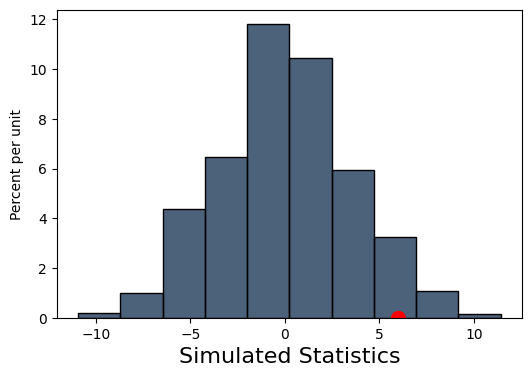

In [ ]:
import matplotlib.pyplot as plt
t = Table().with_column('Simulated Statistics', simulated_statistics)
t.hist()
%matplotlib inline
plt.scatter(observed_statistic, 0, color='red', s=100, zorder=2);
plt.show()

We can make a visual argument as to whether we believe the observed statistic is consistent with Emily’s model. Here, since larger values of the test statistic suggest the alternative model (where the chance of guessing the correct hand is something other than 50%), we can formalize our analysis by finding what proportion of simulated statistics were as large or larger than our observed test statistic (the area at or to the right of the observed test statistic). If this area is small enough, we’ll declare that the observed data are inconsistent with our simulated model. Here is the link to the section in the textbook.

In [ ]:
#The observed test statistic is not consistent with Emily's model.
#This is because the area to the right of the observed statistic is not
#significant enough for the observed value to be considered
#consistent with the model.

### Question 9:

Calculate the proportion of simulated statistics greater than or equal to the observed statistic.

Hint: `np.count_nonzero` usage can be found here.

In [ ]:
simulated_statistics = np.array(simulated_statistics)
proportion_greater_or_equal = np.count_nonzero(simulated_statistics >= observed_statistic) / len(simulated_statistics)
proportion_greater_or_equal

0.051

By convention, we often compare the proportion we just calculated to 0.05. If the proportion of simulated statistics greater than or equal to the observed statistic is sufficiently small (less than or equal to 0.05), then this is evidence against Emily's model. Conceptually, you may think of this as the case where less than 5% of simulated values are as far or farther away from what we had expected. If this is not the case, we don’t have any reason to doubt Emily’s model.

This should help you make your own conclusions about Emily Rosa's experiment.

Therapeutic touch fell out of use after this experiment, which was eventually accepted into one of the premier medical journals. TT practitioners hit back and accused Emily and her family of tampering with the results, while some claimed that Emily's bad spiritual mood towards therapeutic touch made it difficult to read her HEF. Whatever it may be, Emily's experiment is a classic example about how anyone, with the right resources, can test anything they want!

In [ ]:
#The proportion of simulated staistics is very close to 0.05 (+0.01).
#According the information provided above, this technically is evidence
#proving Emily's model which states that the TT practitioner's really did
#guessed a hand like a coin flip

###Question 10:

Now, take some time to think to yourself and discuss with your peers:

1. Is the data more consistent with Emily' model (practioners were randomly guessing)?
2. What does this mean in terms of Emily's experiment? Do the TT practitioners' answers follow an even chance model or is there something else at play?

Did you talk to your peers? (T/F)

In [ ]:
#Q1: The data is consistent with Emily's model as stated above, so we can
#conclude that the practioners were randomly guessing

#Q2: In term's of Emilys experiment, we have proved her model correct by
#calculating the proportion of simulated statistics greater than or equal to
#the proportion of observed statistics. The TT practitioners' answers do
#follow an even chance model just like a coin toss where they were highly
#likely to pick a random hand. There could have been other confounding
#factor's present at the time of the test such as Emily's gaze or expression
#which could have influenced the practitioner's guess.

In [ ]:
peer_talk = True
peer_talk